In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import random
import matplotlib.pyplot as plt

In [2]:
KEY_LENGTH = 1024

alice_bits  = [random.randint(0, 1) for _ in range(KEY_LENGTH)]
alice_bases = [random.randint(0, 1) for _ in range(KEY_LENGTH)]  # 0=rectilinear, 1=diagonal

print("Alice's bits:  ", alice_bits)
print("Alice's bases: ", alice_bases, "(0=+, 1=×)")

Alice's bits:   [0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,

Encoded 1024 qubits.


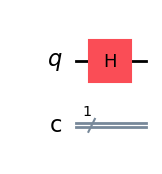

In [3]:
def encode_qubit(bit, basis):
    qc = QuantumCircuit(1, 1)
    if bit == 1:
        qc.x(0)          # Flip to |1⟩
    if basis == 1:
        qc.h(0)          # Diagonal basis
    return qc

alice_qubits = [encode_qubit(b, base) for b, base in zip(alice_bits, alice_bases)]
print(f"Encoded {len(alice_qubits)} qubits.")

# Visualize one example circuit
alice_qubits[0].draw("mpl")

In [4]:
sim = AerSimulator()

bob_bases = [random.randint(0, 1) for _ in range(KEY_LENGTH)]
bob_results = []

# Build all circuits at once
circuits = []
for i, qc in enumerate(alice_qubits):
    measure_qc = qc.copy()
    if bob_bases[i] == 1:
        measure_qc.h(0)
    measure_qc.measure(0, 0)
    circuits.append(transpile(measure_qc, sim))

# Run all in one batch
results = sim.run(circuits, shots=1).result()
bob_results = [int(list(results.get_counts(i).keys())[0]) for i in range(KEY_LENGTH)]

print("Bob's bases:   ", bob_bases)
print("Bob's results: ", bob_results)

Bob's bases:    [1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,

In [5]:
sifted_alice = []
sifted_bob   = []
matching_indices = []

for i in range(KEY_LENGTH):
    if alice_bases[i] == bob_bases[i]:
        sifted_alice.append(alice_bits[i])
        sifted_bob.append(bob_results[i])
        matching_indices.append(i)

print(f"Matching bases at positions: {matching_indices}")
print(f"Sifted key length: {len(sifted_alice)} bits (from {KEY_LENGTH} original)")
print(f"Alice's sifted key: {sifted_alice}")
print(f"Bob's sifted key:   {sifted_bob}")

Matching bases at positions: [0, 2, 7, 9, 13, 14, 16, 17, 18, 20, 23, 24, 25, 27, 30, 33, 38, 40, 41, 43, 44, 45, 48, 57, 61, 65, 68, 71, 72, 74, 79, 81, 83, 86, 87, 89, 90, 91, 93, 96, 97, 102, 104, 105, 106, 107, 108, 112, 114, 115, 116, 118, 120, 122, 124, 128, 129, 134, 135, 137, 138, 139, 140, 141, 142, 144, 145, 146, 148, 150, 151, 153, 154, 158, 160, 161, 162, 165, 167, 168, 169, 170, 171, 174, 175, 176, 178, 181, 182, 183, 184, 185, 186, 188, 189, 190, 191, 197, 199, 204, 207, 208, 209, 210, 211, 214, 218, 219, 222, 223, 225, 231, 237, 239, 243, 244, 245, 247, 248, 249, 250, 253, 255, 256, 257, 258, 261, 262, 264, 265, 267, 271, 273, 274, 276, 278, 279, 281, 282, 283, 286, 287, 288, 289, 290, 291, 292, 293, 296, 299, 300, 304, 305, 309, 310, 311, 312, 314, 316, 317, 318, 320, 322, 325, 326, 327, 329, 331, 333, 334, 338, 339, 340, 341, 342, 343, 351, 352, 354, 356, 358, 359, 363, 364, 365, 371, 372, 379, 382, 384, 386, 387, 388, 390, 391, 394, 395, 396, 398, 401, 402, 404, 405, 

In [6]:

def simulate_eve(alice_qubits, intercept_rate=1.0):
    eve_bases = [random.randint(0, 1) for _ in range(len(alice_qubits))]

    # Build all Eve's measurement circuits at once
    eve_circuits = []
    intercepted = []
    for i, qc in enumerate(alice_qubits):
        if random.random() < intercept_rate:
            eve_qc = qc.copy()
            if eve_bases[i] == 1:
                eve_qc.h(0)
            eve_qc.measure(0, 0)
            eve_circuits.append((i, transpile(eve_qc, sim)))
            intercepted.append(i)

    # Run all Eve's measurements in one batch
    eve_results = {}
    if eve_circuits:
        indices, circuits = zip(*eve_circuits)
        batch_results = sim.run(list(circuits), shots=1).result()
        for j, idx in enumerate(indices):
            eve_results[idx] = int(list(batch_results.get_counts(j).keys())[0])

    # Re-encode qubits Eve intercepted
    disturbed_qubits = []
    for i, qc in enumerate(alice_qubits):
        if i in eve_results:
            new_qc = QuantumCircuit(1, 1)
            if eve_results[i] == 1:
                new_qc.x(0)
            if eve_bases[i] == 1:
                new_qc.h(0)
            disturbed_qubits.append(new_qc)
        else:
            disturbed_qubits.append(qc)

    return disturbed_qubits

def calculate_error_rate(alice_key, bob_key):
    errors = sum(a != b for a, b in zip(alice_key, bob_key))
    return errors / len(alice_key) if alice_key else 0

print("Eve simulation functions defined.")

Eve simulation functions defined.


In [ ]:
scenarios = {
    "No Eve (0%)":         0.00,
    "Eve intercepts 25%":  0.25,
    "Eve intercepts 50%":  0.50,
    "Eve intercepts 75%":  0.75,
    "Eve intercepts 100%": 1.00,
}

print("=" * 50)
print(f"{'Scenario':<25} {'Error Rate':>10} {'Detected?':>10}")
print("=" * 50)

for label, rate in scenarios.items():
    # Apply Eve's interception
    qubits_after_eve = simulate_eve(alice_qubits, intercept_rate=rate)

    # Build all of Bob's measurement circuits at once
    circuits = []
    for i, qc in enumerate(qubits_after_eve):
        measure_qc = qc.copy()
        if bob_bases[i] == 1:
            measure_qc.h(0)
        measure_qc.measure(0, 0)
        circuits.append(transpile(measure_qc, sim))

    # Run all circuits in one batch
    results = sim.run(circuits, shots=1).result()
    bob_results_eve = [int(list(results.get_counts(i).keys())[0]) for i in range(KEY_LENGTH)]

    # Sift and check error rate
    s_alice, s_bob = [], []
    for i in matching_indices:
        s_alice.append(alice_bits[i])
        s_bob.append(bob_results_eve[i])

    error_rate = calculate_error_rate(s_alice, s_bob)
    detected = "YES ⚠️" if error_rate > 0.1 else "No ✅"
    print(f"{label:<25} {error_rate:>9.1%} {detected:>10}")

print("=" * 50)

Scenario                  Error Rate  Detected?
No Eve (0%)                    0.0%       No ✅
Eve intercepts 25%             5.1%       No ✅
Eve intercepts 50%            13.1%     YES ⚠️
Eve intercepts 75%            20.1%     YES ⚠️
Eve intercepts 100%           24.8%     YES ⚠️


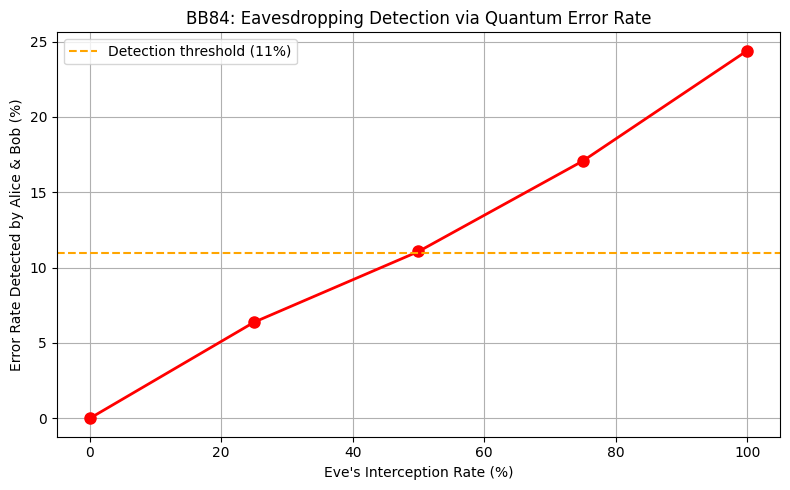

In [8]:
intercept_rates = [0.0, 0.25, 0.5, 0.75, 1.0]
error_rates = []

for rate in intercept_rates:
    disturbed = simulate_eve(alice_qubits, intercept_rate=rate)

    # Build all circuits at once
    circuits = []
    for i, qc in enumerate(disturbed):
        measure_qc = qc.copy()
        if bob_bases[i] == 1:
            measure_qc.h(0)
        measure_qc.measure(0, 0)
        circuits.append(transpile(measure_qc, sim))

    # Run in one batch
    results = sim.run(circuits, shots=1).result()
    bob_r = [int(list(results.get_counts(i).keys())[0]) for i in range(KEY_LENGTH)]

    s_a, s_b = [], []
    for i in matching_indices:
        s_a.append(alice_bits[i])
        s_b.append(bob_r[i])
    error_rates.append(calculate_error_rate(s_a, s_b))

plt.figure(figsize=(8, 5))
plt.plot([r * 100 for r in intercept_rates],
         [e * 100 for e in error_rates],
         'ro-', linewidth=2, markersize=8)
plt.axhline(y=11, color='orange', linestyle='--', label='Detection threshold (11%)')
plt.xlabel("Eve's Interception Rate (%)")
plt.ylabel("Error Rate Detected by Alice & Bob (%)")
plt.title("BB84: Eavesdropping Detection via Quantum Error Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()